In [1]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

temp = pd.Series([-0.8, -0.1, 7.7, 13.8, 18.0, 22.4,
                  25.9, 25.3, 21.0, 14.0, 9.6, -1.4])
print(temp)

0     -0.8
1     -0.1
2      7.7
3     13.8
4     18.0
5     22.4
6     25.9
7     25.3
8     21.0
9     14.0
10     9.6
11    -1.4
dtype: float64


In [3]:
print(temp.index)
temp.index = ["1월", "2월", "3월", "4월",
              "5월", "6월", "7월", "8월",
              "9월", "10월", "11월", "12월"]
print(temp)

RangeIndex(start=0, stop=12, step=1)
1월     -0.8
2월     -0.1
3월      7.7
4월     13.8
5월     18.0
6월     22.4
7월     25.9
8월     25.3
9월     21.0
10월    14.0
11월     9.6
12월    -1.4
dtype: float64


---
### 인덱싱과 슬라이싱

In [4]:
print(temp.iloc[2])

7.7


In [5]:
print(temp.loc["3월"])

7.7


In [6]:
rows = [3, 5, 7]
print(temp.iloc[[3, 5 ,7]])

4월    13.8
6월    22.4
8월    25.3
dtype: float64


In [7]:
idx = np.array([3, 5, 7])
print(temp.iloc[idx])

4월    13.8
6월    22.4
8월    25.3
dtype: float64


In [8]:
print(temp.loc[["4월", "6월", "8월"]])

4월    13.8
6월    22.4
8월    25.3
dtype: float64


In [9]:
print(temp.iloc[5:8])

6월    22.4
7월    25.9
8월    25.3
dtype: float64


In [10]:
print(temp.loc["6월":"9월"])

6월    22.4
7월    25.9
8월    25.3
9월    21.0
dtype: float64


In [11]:
print(temp.iloc[:4])

1월    -0.8
2월    -0.1
3월     7.7
4월    13.8
dtype: float64


In [12]:
print(temp.iloc[9:])

10월    14.0
11월     9.6
12월    -1.4
dtype: float64


In [13]:
print(temp.iloc[:])

1월     -0.8
2월     -0.1
3월      7.7
4월     13.8
5월     18.0
6월     22.4
7월     25.9
8월     25.3
9월     21.0
10월    14.0
11월     9.6
12월    -1.4
dtype: float64


In [14]:
print(temp.iloc[::-1])

12월    -1.4
11월     9.6
10월    14.0
9월     21.0
8월     25.3
7월     25.9
6월     22.4
5월     18.0
4월     13.8
3월      7.7
2월     -0.1
1월     -0.8
dtype: float64


---
### 조건문을 이용한 슬라이싱
- 조건을 이용한 데이터 추출(Boolean Indexing)
    - 시리즈 내의 모든 요소들을 조건과 비교하여 조건에 맞으면 True, 맞지 않으면 False로 구성된 불리언(True/False) 시리즈가 반환됩니다.
    - 다중 조건(Logical Operators)
        - 여러 조건을 결합할 때는 파이썬의 and, or 대신 비트 연산자를 사용하며, 각 조건은 반드시 괄호로 묶어야 합니다.
        - AND 연산 (&): 두 조건이 모두 참일 때
            - temp.loc[(temp >= 15) & (temp <= 25)]
        - OR 연산 (|): 두 조건 중 하나라도 참일 때
            - temp.loc[(temp < 10) | (temp > 30)]
        - NOT 연산 (~): 조건을 반전시킬 때 (True <-> False)
            - temp.loc[~(temp < 15)] (15 미만이 아닌 것 = 15 이상인 것)

In [15]:
# 정수 값으로 이루어진 Pandas Series 생성
s = pd.Series([10, 20, 30])

# Series의 각 요소를 15와 비교합니다.
# 요소별로 비교가 수행되어 True / False 값으로 이루어진
# 새로운 Boolean Series가 반환됩니다.
print(s >= 15)

0    False
1     True
2     True
dtype: bool


In [16]:
print(s < 25)

0     True
1     True
2    False
dtype: bool


In [17]:
print((s > 15) & (s < 25))

0    False
1     True
2    False
dtype: bool


In [18]:
print(temp >= 15)

1월     False
2월     False
3월     False
4월     False
5월      True
6월      True
7월      True
8월      True
9월      True
10월    False
11월    False
12월    False
dtype: bool


In [19]:
result = temp.loc[temp >= 15]
print(type(result))

<class 'pandas.Series'>


In [20]:
print(result)

5월    18.0
6월    22.4
7월    25.9
8월    25.3
9월    21.0
dtype: float64


In [21]:
print(temp.loc[(temp >= 15) & (temp < 25)])

5월    18.0
6월    22.4
9월    21.0
dtype: float64


In [22]:
print(temp.loc[(temp < 5) | (temp >= 25)])

1월     -0.8
2월     -0.1
7월     25.9
8월     25.3
12월    -1.4
dtype: float64


In [23]:
print(temp.loc[~(temp < 15)])

5월    18.0
6월    22.4
7월    25.9
8월    25.3
9월    21.0
dtype: float64


In [24]:
print(temp.loc[temp < temp.loc["3월"]])

1월    -0.8
2월    -0.1
12월   -1.4
dtype: float64


---
### where()을 이용한 조건 검색
- temp.where(조건)은 시리즈의 모든 요소를 검사여 조건이 True인 경우는 원래 값을 그대로 유지합니다.
- 조건이 False이면 값을 버리지 않고 NaN(결측치, Not a Number)으로 변경합니다.
- 결측치는 값이 비어 있는 상태로 NaN(Not a Number)으로 표시됩니다.

In [25]:
print(temp.where(temp >= 15))

1월      NaN
2월      NaN
3월      NaN
4월      NaN
5월     18.0
6월     22.4
7월     25.9
8월     25.3
9월     21.0
10월     NaN
11월     NaN
12월     NaN
dtype: float64


In [26]:
print(temp.where(temp >= 15).dropna())

5월    18.0
6월    22.4
7월    25.9
8월    25.3
9월    21.0
dtype: float64


---
### 조건에 맞는 값의 위치 찾기

In [27]:
print(temp.where(temp >= 15).dropna().index)

Index(['5월', '6월', '7월', '8월', '9월'], dtype='str')


---
### 산술 연산
- 시리즈 객체에 대한 산술 연산은 각각의 값에 대해 실행이 됩니다.
- Pandas의 시리즈에 숫자 하나를 더하면, 반복문을 쓰지 않아도 모든 요소에 각각 1씩 더해집니다. 이를 브로드캐스팅(Broadcasting)이라고 합니다.

In [28]:
print(temp)

1월     -0.8
2월     -0.1
3월      7.7
4월     13.8
5월     18.0
6월     22.4
7월     25.9
8월     25.3
9월     21.0
10월    14.0
11월     9.6
12월    -1.4
dtype: float64


In [29]:
print(temp + 1)

1월      0.2
2월      0.9
3월      8.7
4월     14.8
5월     19.0
6월     23.4
7월     26.9
8월     26.3
9월     22.0
10월    15.0
11월    10.6
12월    -0.4
dtype: float64


In [30]:
print(temp + temp)

1월     -1.6
2월     -0.2
3월     15.4
4월     27.6
5월     36.0
6월     44.8
7월     51.8
8월     50.6
9월     42.0
10월    28.0
11월    19.2
12월    -2.8
dtype: float64


In [31]:
print(temp.loc[temp >= 15] + 1)

5월    19.0
6월    23.4
7월    26.9
8월    26.3
9월    22.0
dtype: float64


### 시리즈 통계 관련 메서드
- 기본적으로 결측치를 제외하는 통계 메서드 (skipna=True)

| 메서드 | 의미 | 특징 |
| :--- | :--- | :--- |
| `count()` | 값의 개수 | `NaN`제외 |
| `sum()` | 합계 | 숫자만 대상 |
| `mean()` | 평균 | 산술 평균 |
| `median()` | 중앙값 | 이상치에 강함 |
| `mode()` | 최빈값 | 여러 개일 수 있음 |
| `min()` | 최솟값 |  |
| `max()` | 최댓값 |  |
| `var()` | 표본 분산 |  |
| `std()` | 표본 표준편차 |  |
| `describe()` | 요약 통계 | count, mean, std, min, 25%, 50%, 75%, max |

In [32]:
print(temp.count())

12


In [33]:
print(temp.sum())

155.39999999999998


In [34]:
print(temp.mean())
print(temp.sum() / temp.count()) # 다른 방식

12.949999999999998
12.949999999999998


In [37]:
sorted_temp = temp.sort_values()
print(sorted_temp)

12월    -1.4
1월     -0.8
2월     -0.1
3월      7.7
11월     9.6
4월     13.8
10월    14.0
5월     18.0
9월     21.0
6월     22.4
8월     25.3
7월     25.9
dtype: float64


In [35]:
print(temp.median()) # 값이 짝수면 중앙값 2개의 합을 2로 나눈다.

13.9


In [36]:
print(temp.mode())

0     -1.4
1     -0.8
2     -0.1
3      7.7
4      9.6
5     13.8
6     14.0
7     18.0
8     21.0
9     22.4
10    25.3
11    25.9
dtype: float64


In [38]:
print(temp.min())

-1.4


In [39]:
print(temp.max())

25.9


---
### 판다스 분산은 ddof=1로 표본 분산을 구합니다.

In [40]:
print(temp.var())

100.52090909090909


In [41]:
print(temp.var(ddof=0))

92.14416666666666


---
### 넘파이의 분산은 기본 설정 ddof=0으로 모집단 분산을 구합니다.

In [42]:
numpy_data = temp.to_numpy()
print(np.var(numpy_data))

92.14416666666666


In [43]:
print(np.var(numpy_data, ddof=1))

100.52090909090909


---
사분위수(Quartiles)란

데이터의 분포를 이해할 때, 평균만으로는 부족한 경우가 많습니다.<br>
이때 데이터를 같은 개수 기준으로 나누어 위치를 파악하는 방법이 사분위수(Quartile)입니다.

사분위수(Quatile)란,<br>
👉 데이터를 오름차순으로 정렬한 뒤<br>
👉 전체 데이터를 4등분 했을 때의 기준이 되는 값입니다.

| **구분** | **이름** | **의미** | **퍼센트 위치** |
| :--- | :--- | :--- | :--- |
| **Q1** | 1사분위수 | 하위 25% 지점 | 25% |
| **Q2** | 2사분위수 | 중앙값 (Median) | 50% |
| **Q3** | 3사분위수 | 하위 75% 지점 | 75% |

- 평균은 같아도 분포는 다를 수 있습니다.

- 사분위수는 데이터 퍼짐을 잘 보여줍니다.

- 이상치 판단<br>
정상 범위를 벗어난 데이터를 찾기 위해 IQR의 1.5배를 기준으로 경계값을 설정합니다.<br>
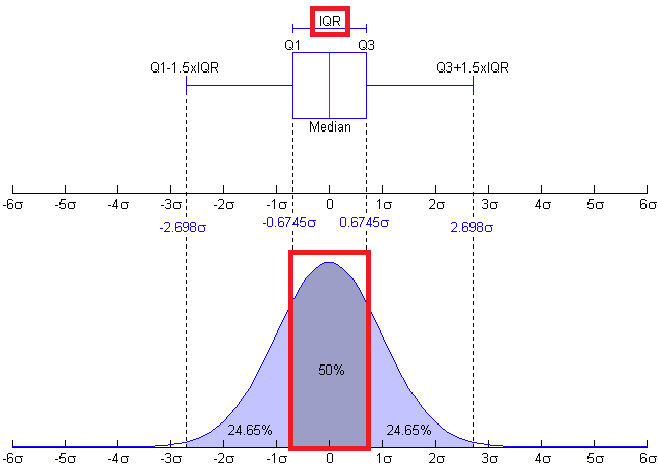
    - https://blog.naver.com/sw4r/221021173204
    - 우리가 수집하는 많은 데이터는 평균을 중심으로 종 모양을 그리는 정규분포를 따르는 경우가 많습니다.
    - 만약 데이터가 정규분포를 따른다고 가정할 때:
        - IQR=Q3-Q1 일 때 (데이터의 중간 50%가 모여있는 구간)
        - 아래 범위를 벗어날 확률은 약 0.7% 입니다.
            - 값 < (Q1 - 1.5 * IQR)<br>or<br>값 > (Q3 + 1.5 * IQR)<br>=> 1,000개 중에 7개 정도 나올 법한 아주 희귀한 값을 이상치로 정의합니다.

In [44]:
print(temp.describe())

count    12.000000
mean     12.950000
std      10.026012
min      -1.400000
25%       5.750000
50%      13.900000
75%      21.350000
max      25.900000
dtype: float64


---
### 시리즈 객체에 대한 값의 수정, 추가 삭제

In [45]:
no_label_series = pd.Series([20, 15, 18, 30]) # 레이블 인덱스가 없는 시리즈 객체
label_series = pd.Series([75, 80, 90, 60], index=["KOR", "ENG", "MATH", "SOC"])

In [46]:
print(no_label_series)

0    20
1    15
2    18
3    30
dtype: int64


In [47]:
print(label_series)

KOR     75
ENG     80
MATH    90
SOC     60
dtype: int64


In [48]:
label_series.iloc[0] = 85
print(label_series)

KOR     85
ENG     80
MATH    90
SOC     60
dtype: int64


In [49]:
label_series.loc["SOC"] = 65
print(label_series)

KOR     85
ENG     80
MATH    90
SOC     65
dtype: int64


In [50]:
result = label_series.loc[["ENG", "MATH"]]
print(result)

ENG     80
MATH    90
dtype: int64


In [51]:
label_series.loc[["ENG", "MATH"]] = [100, 100]
print(label_series)

KOR      85
ENG     100
MATH    100
SOC      65
dtype: int64


---
2. 추가
- loc() 활용

In [52]:
label_series.loc["PHY"] = 50
print(label_series)

KOR      85
ENG     100
MATH    100
SOC      65
PHY      50
dtype: int64


In [53]:
label_series.iloc[5] = 90
print(label_series)

IndexError: iloc cannot enlarge its target object

In [54]:
next_idx = no_label_series.size
print(next_idx)

4


In [55]:
no_label_series.iloc[next_idx] = 33

IndexError: iloc cannot enlarge its target object

---
- pd.concat()은 Concatenate(연결하다)의 약자로, 여러 개의 판다스 객체(Series 또는 DataFrame)를 가로(열)나 세로(행) 방향으로 물리적으로 붙이는 함수입니다.
- 여러 개의 시리즈나 데이터프레임을 리스트 [] 형태로 묶어서 전달해야 합니다.

In [56]:
score = pd.Series([80, 90])
new = pd.Series([100])

score = pd.concat([score, new])
print(score)

0     80
1     90
0    100
dtype: int64


In [57]:
score = pd.Series([80, 90])
new = pd.Series([100])

score = pd.concat([score, new], ignore_index=True)
print(score)

0     80
1     90
2    100
dtype: int64


In [58]:
s1 = pd.Series([10, 20], index=["A", "B"])
s2 = pd.Series([30, 40], index=["C", "D"])

result = pd.concat([s1, s2]) # axis=0 is default. row appending
print(result)

A    10
B    20
C    30
D    40
dtype: int64


In [60]:
s1 = pd.Series([10, 20])
s2 = pd.Series([30, 40])

result = pd.concat([s1, s2], axis=1)
print(result)

    0   1
0  10  30
1  20  40


---
3. 삭제
- index=["KOR", "ENG", "MATH", "SOC", "PHY", "MUS"] 설정한 경우

In [61]:
score = pd.Series([85, 70, 80, 65, 50, 95], index=["KOR", "ENG", "MATH", "SOC", "PHY", "MUS"])
print(score)

KOR     85
ENG     70
MATH    80
SOC     65
PHY     50
MUS     95
dtype: int64


In [63]:
score.drop("PHY") # 원본을 수정하지 않음
print(score)

KOR     85
ENG     70
MATH    80
SOC     65
PHY     50
MUS     95
dtype: int64


In [64]:
score = score.drop("PHY")
print(score)

KOR     85
ENG     70
MATH    80
SOC     65
MUS     95
dtype: int64


---
- 객체 참조 방식

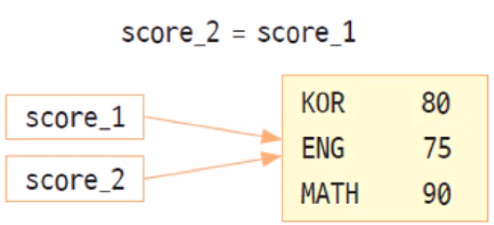

In [67]:
score_1 = pd.Series([80, 75, 90], index=["KOR", "ENG", "MATH"])

score_2 = score_1
score_2.loc["KOR"] = 95

print(score_2)

KOR     95
ENG     75
MATH    90
dtype: int64


In [68]:
print(id(score_1) == id(score_2))

True


In [69]:
print(score_1)

KOR     95
ENG     75
MATH    90
dtype: int64


---
깊은 복사(Deep Copy)

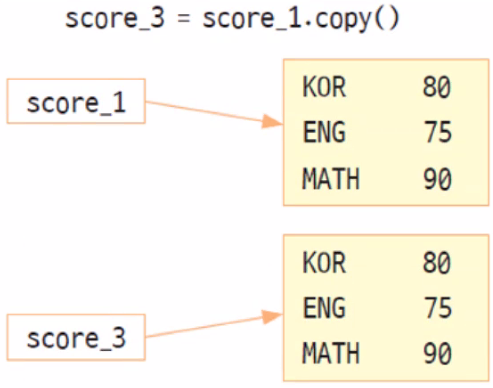

- 판다스 .copy()의 기본 값은 deep=True(깊은 복사) 입니다.
- deep = True인 경우를 Deep Copy라고 하며 원본과는 완전하게 별개인 복사본이 생성됩니다. 사본과 원본의 수정은 서로에게 영향을 끼치지 않습니다.

In [70]:
original = pd.Series([80, 75, 90], index=["KOR", "ENG", "MATH"])
score_3 = original.copy()
score_3.loc["KOR"] = 70
print(score_3)

KOR     70
ENG     75
MATH    90
dtype: int64


In [71]:
print(id(original) == id(score_3))

False


In [72]:
print(original)

KOR     80
ENG     75
MATH    90
dtype: int64
